# Introduction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df_season = pd.read_excel(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\Season Summary Analysis.xlsx", 
                          sheet_name="Season  Summary")
df_market = pd.read_excel(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\Season Summary Analysis.xlsx", 
                          sheet_name="Market Size")
df_results = pd.read_csv(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\NBA All playoff participating team.csv") 

# Analysis

## Season Summary

In [10]:
df_season

,Season,Lg,Champion,MVP,Rookie of the Year,Points,Rebounds,Assists,Win Shares
0,2024-25,NBA,NaN,NaN,NaN,S. Gilgeous-Alexander (1957),D. Sabonis (792),T. Young (668),S. Gilgeous-Alexander (13.6)
1,2023-24,NBA,Boston Celtics,N. Jokić,V. Wembanyama,L. Dončić (2370),D. Sabonis (1120),T. Haliburton (752),N. Jokić (17.0)
2,2022-23,NBA,Denver Nuggets,J. Embiid,P. Banchero,J. Tatum (2225),D. Sabonis (973),T. Young (741),N. Jokić (14.9)
3,2021-22,NBA,Golden State Warriors,N. Jokić,S. Barnes,T. Young (2155),N. Jokić (1019),T. Young (737),N. Jokić (15.2)
4,2020-21,NBA,Milwaukee Bucks,N. Jokić,L. Ball,S. Curry (2015),R. Gobert (960),R. Westbrook (763),N. Jokić (15.6)
...,...,...,...,...,...,...,...,...,...
83,1950-51,NBA,Rochester Royals,NaN,P. Arizin,G. Mikan (1932),D. Schayes (1080),A. Phillip (414),G. Mikan (23.4)
84,1949-50,NBA,Minneapolis Lakers,NaN,A. Groza,G. Mikan (1865),NaN,D. McGuire (386),G. Mikan (21.1)
85,1948-49,BAA,Minneapolis Lakers,NaN,H. Shannon,G. Mikan (1698),NaN,B. Davies (321),G. Mikan (20.9)
86,1947-48,BAA,Baltimore Bullets,NaN,P. Hoffman,M. Zaslofsky (1007),NaN,H. Dallmar (120),B. Feerick (10.5)


In [3]:
df_market.rename(columns={'Team' : 'Champion'}, inplace=True)

In [4]:
working_df = pd.merge(df_season[['Season', 'Champion']], df_market[['Champion', 'Segment']], 
                      on=['Champion'])

In [5]:
working_df['date'] = working_df['Season'].str[:4].astype(int)

In [6]:
working_df['Before_regulation'] = working_df['date'].apply(
    lambda row: 1 if row < 1984 else 0
)

In [17]:
working_df['Segment'].value_counts()/len(working_df)

Segment
Large-market    0.731343
Small-market    0.149254
Mid-market      0.119403
Name: count, dtype: float64

In [ ]:
#Proportion for each period
class_counts = working_df.groupby(['Segment', 'Before_regulation']).size().unstack(fill_value=0)

#Proportions
class_proportions = class_counts.div(class_counts.sum(axis=0), axis=1)

In [12]:
working_df[working_df['Champion'] == 'Cleveland Cavaliers']

,Season,Champion,Segment,date,Before_regulation
8,2015-16,Cleveland Cavaliers,Mid-market,2015,0


In [34]:
class_counts

Before_regulation,0,1
Segment,,
Large-market,26,23
Mid-market,8,0
Small-market,6,4


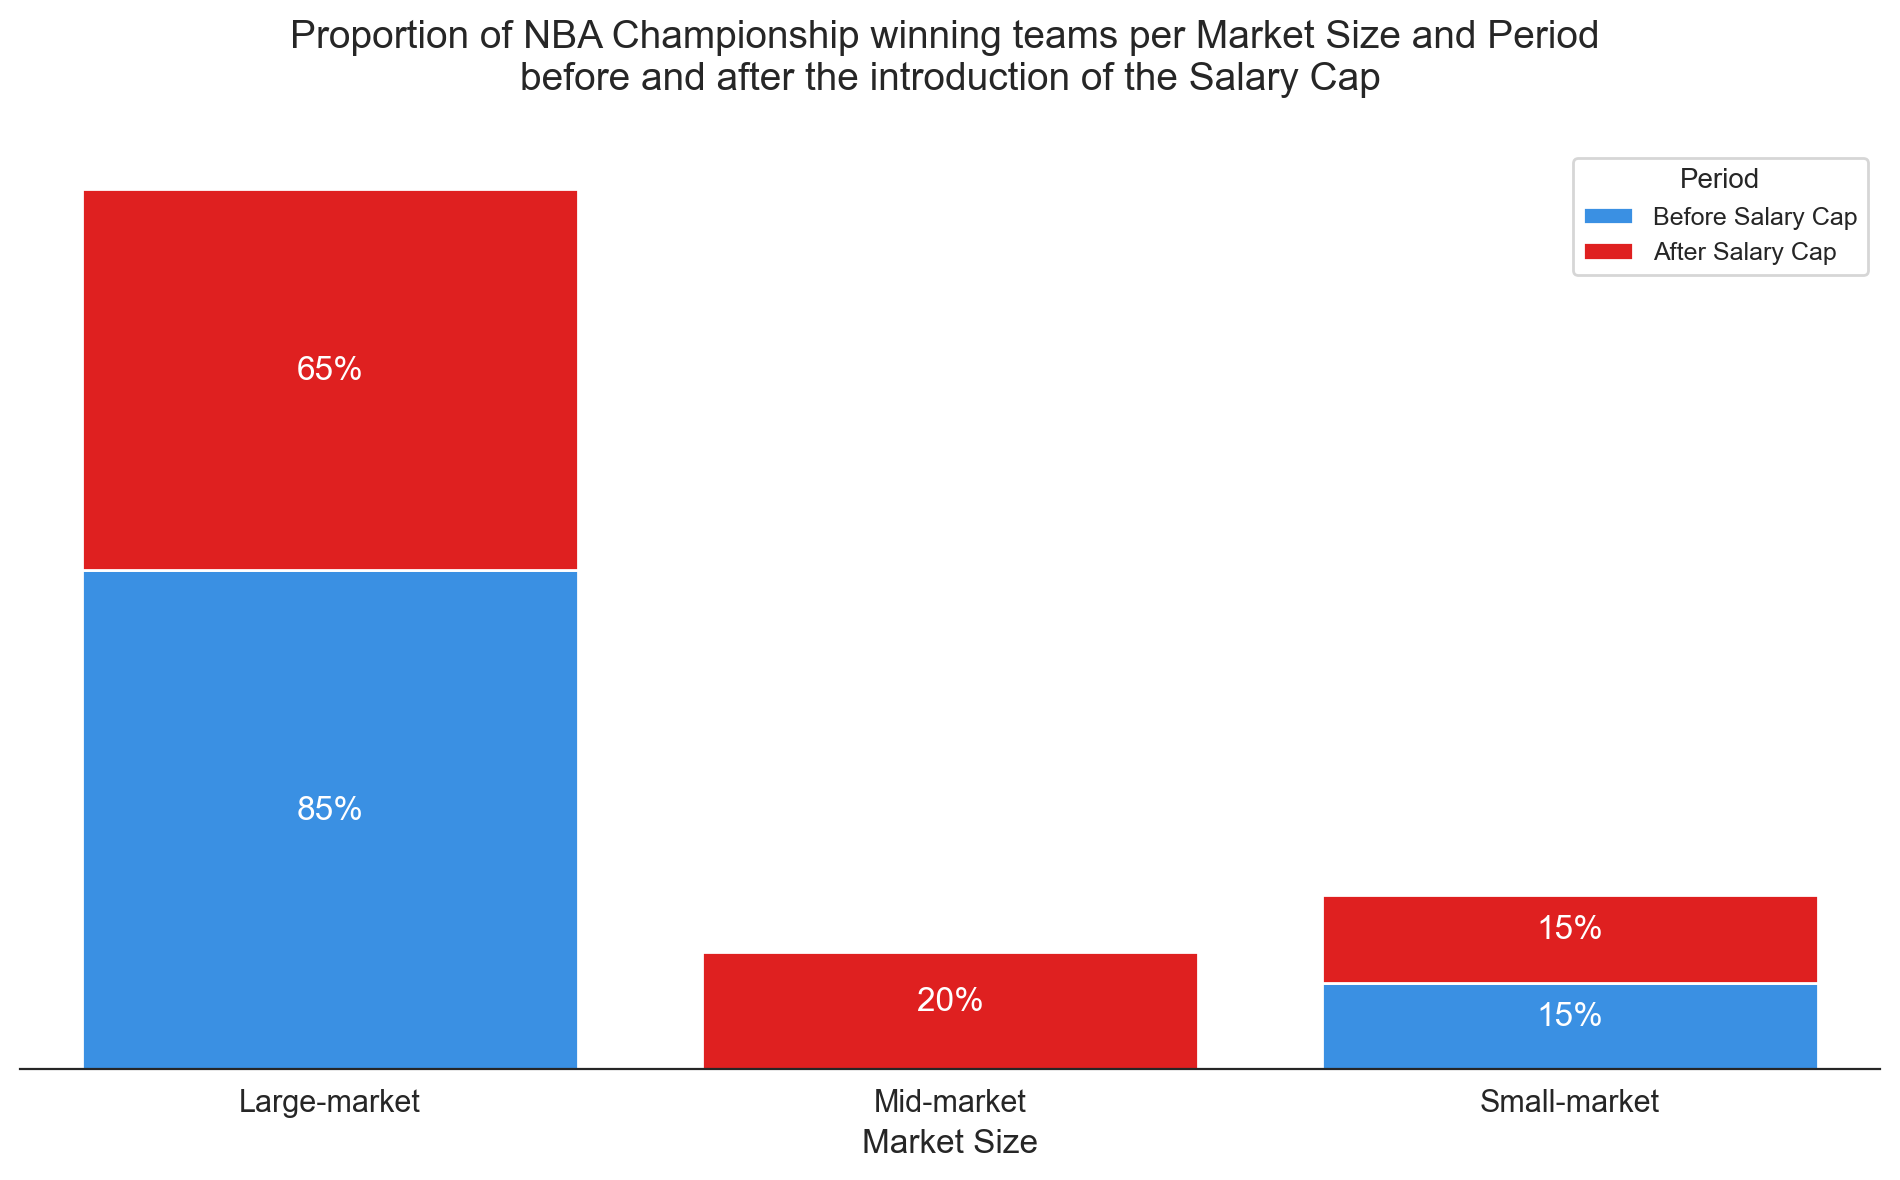

In [ ]:
colors = ['#1E90FF', '#FF0000']  # Flashy Blue and Red (NBA Style)

plt.figure(figsize=(12, 6), dpi=200)
sns.set_style('white')


sns.barplot(data=class_proportions, x='Segment', y=1, color=colors[0], label='Before Salary Cap')
sns.barplot(data=class_proportions, x='Segment', y=0, color=colors[1], label='After Salary Cap', bottom=class_proportions[1])
plt.xlabel('Market Size', fontsize=12)
plt.ylabel('')
plt.title('Proportion of NBA Championship winning teams per Market Size and Period \nbefore and after the introduction of the Salary Cap', fontsize=14, pad=20)
plt.legend(title='Period', fontsize=9)

plt.xticks(['Large-market', 'Mid-market', 'Small-market'], fontsize=11)  #Rotates labels
plt.yticks([])
sns.despine(left=True)

#Text annotation
for i in range(2):
    for j in class_proportions[i].index:
        count = class_proportions[i][j]
        if count != 0:
            if i == 1:    
                height = class_proportions[i][j]/2
            else:
                height = class_proportions[i][j]/2 + class_proportions[1][j]
            plt.text(x=j, y=height, s=str((class_proportions[i][j].round(2))*100)[:-2]+"%", 
                     fontsize=12, color='white', ha="center")

plt.show()

In [ ]:
#Calculation of probablity (Bayesian prob)
from scipy.stats import beta

#Pre-cap
alpha_pre = 23 + 1 
beta_pre = 27 - alpha_pre #23+1

#Post cap
alpha_post = 26 + 1
beta_post = 40 - alpha_post #26+1

#Prob that p_post < p_pre
samples_pre = beta.rvs(alpha_pre, beta_pre, size=100000)
samples_post = beta.rvs(alpha_post, beta_post, size=100000)
prob_decline = np.mean(samples_post < samples_pre)
print(f"Probability that large-market share declined: {prob_decline:.2%}")

Probability that large-market share declined: 96.31%


## Small/Large market over the years

I want to count per year the number of teams that were SM, MM & LM. Thus 4 columns: Dates-SM-MM-LM.

In [ ]:
#Reshape playoff data 
playoff_long = pd.melt(
    df_results,
    var_name='Year',
    value_name='Team'
).dropna(subset=['Team'])

playoff_long['Year'] = playoff_long['Year'].astype(int)

In [ ]:
#Get the market informaiton
merged_df = pd.merge(playoff_long, df_market, on='Team', how='left')
merged_df = merged_df.dropna(subset=['Segment'])

In [ ]:
#Counting per year and market
counts_df = merged_df.groupby(['Year', 'Segment']).size().reset_index(name='Count')

In [ ]:
#Market size as columns
final_df = counts_df.pivot(
    index='Year',
    columns='Segment',
    values='Count'
).reset_index().fillna(0)
final_df = final_df.sort_values('Year').reset_index(drop=True)

final_df

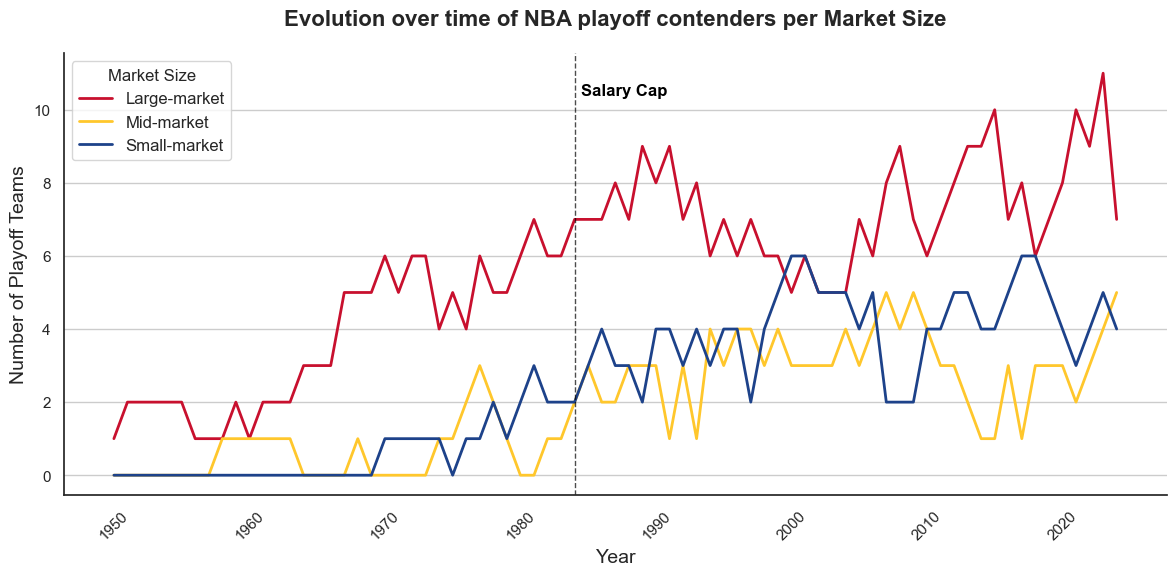

In [ ]:
# Define NBA colors for each market size
nba_colors = {
    'Small-market': '#1D428A',  # NBA blue
    'Mid-market': '#FFC72C',     # NBA gold
    'Large-market': '#C8102E'    # NBA red
}

sns.set(style="white")
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=final_df.melt(id_vars='Year', var_name='Market', value_name='Count'),
    x='Year',
    y='Count',
    hue='Market',
    palette=nba_colors,
    linewidth=2
)

#Line for 1984
plt.axvline(x=1984, color='black', linestyle='--', linewidth=1, alpha=0.7)  # Vertical line
plt.text(1984.5, plt.ylim()[1] * 0.9, 'Salary Cap', color='black', fontsize=12, fontweight='bold')  # Label
plt.gca().xaxis.grid(False)  
plt.gca().yaxis.grid(True)  
sns.set_context("notebook", font_scale=1.2)
plt.title('Evolution over time of NBA playoff contenders per Market Size', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Playoff Teams', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Market Size', title_fontsize=12, fontsize=12)
plt.tight_layout()
sns.despine()
plt.show()

## Win share analysis

In [20]:
df_ws = pd.read_excel(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\Stats\Regular Season.xlsx")

In [ ]:
ws_proportion = {}

for i in range(1, 25):
    total_ws = df_ws[df_ws['season'] == i]['WS'].sum()
    length = len(df_ws[df_ws['season'] == i])
    half_ws = total_ws * 0.5
    df_sorted = df_ws[df_ws['season'] == i].sort_values(by="WS", ascending=False)
    cumulative_ws = 0
    num_players = 0
    for ws in df_sorted["WS"]:
        cumulative_ws += ws
        num_players += 1
        if cumulative_ws >= half_ws:
            break

    ws_proportion[f'Season {str(i)}'] = [num_players/length]
ws_proportion

In [ ]:
#Sort player per WS
df_sorted = df_ws.groupby("season").apply(lambda x: x.sort_values("WS", ascending=False)).reset_index(drop=True)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18192\2440202503.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sorted = df_ws.groupby("season").apply(lambda x: x.sort_values("WS", ascending=False)).reset_index(drop=True)
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18192\2440202503.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_sorted, x="Cumulative_Player_Percentage", y="Cumulative_WS_Percentage",


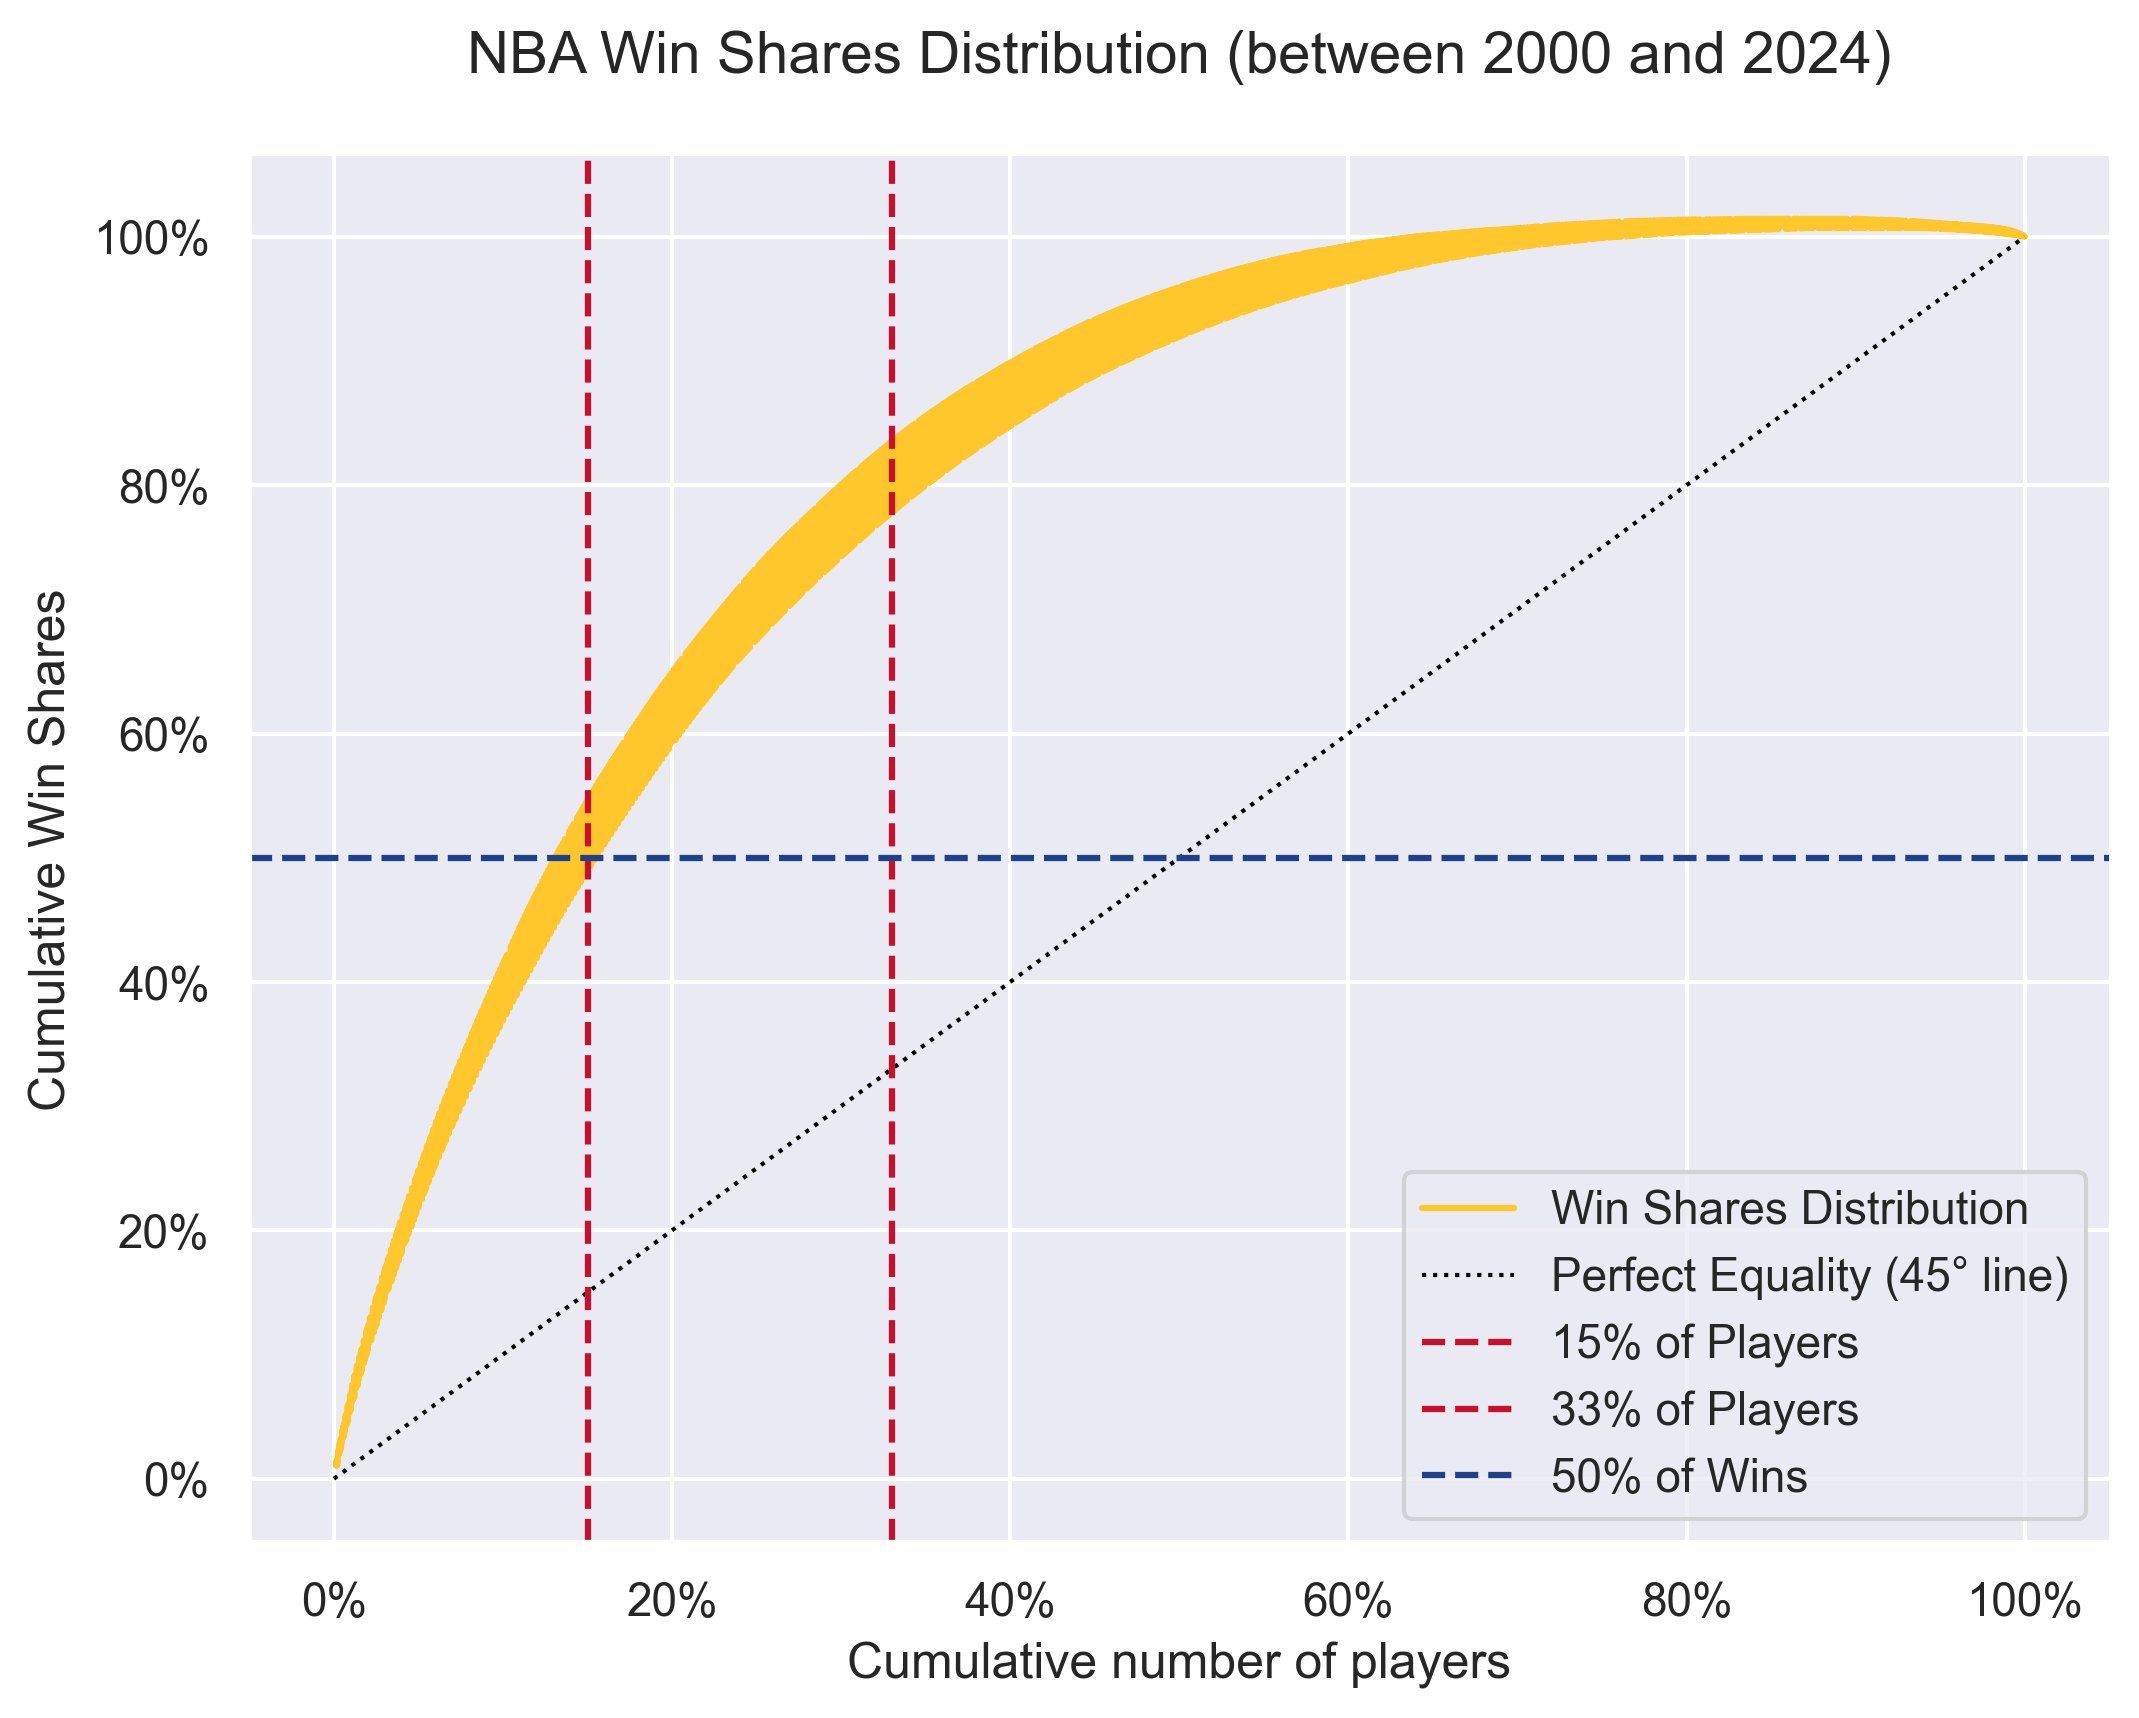

In [ ]:
#Cumul percentage WS
df_sorted["Cumulative_WS"] = df_sorted.groupby("season")["WS"].cumsum()
df_sorted["Total_WS"] = df_sorted.groupby("season")["WS"].transform("sum")
df_sorted["Cumulative_WS_Percentage"] = df_sorted["Cumulative_WS"] / df_sorted["Total_WS"]

In [ ]:
#Cumul percentage player
df_sorted["Player_Count"] = df_sorted.groupby("season").cumcount() + 1
df_sorted["Total_Players"] = df_sorted.groupby("season")["Player"].transform("count")
df_sorted["Cumulative_Player_Percentage"] = df_sorted["Player_Count"] / df_sorted["Total_Players"]

In [ ]:
sns.set(style="dark")
plt.figure(figsize=(8,6), dpi=300)
sns.lineplot(data=df_sorted, x="Cumulative_Player_Percentage", y="Cumulative_WS_Percentage", 
             ci=None, estimator="mean", label="Win Shares Distribution", color='#FFC72C')
plt.plot([0, 1], [0, 1], linestyle=":", color="black", label="Perfect Equality (45° line)",
         lw = 1)

plt.axvline(x=0.15, color='#C8102E', linestyle='--', label="15% of Players")
plt.axvline(x=0.33, color='#C8102E', linestyle='--', label="33% of Players")
plt.axhline(y=0.50, color='#1D428A', linestyle='--', label="50% of Wins")
plt.gca().xaxis.grid(True) 
plt.gca().yaxis.grid(True)
   
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["0%", '20%', '40%', '60%', '80%', '100%'])
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["0%", '20%', '40%', '60%', '80%', '100%'])
plt.xlabel("Cumulative number of players")
plt.ylabel("Cumulative Win Shares")
plt.title("NBA Win Shares Distribution (between 2000 and 2024)",  fontsize=14, pad=20)
plt.legend()
sns.despine()
plt.show();

In [ ]:
# Define NBA colors for each market size
nba_colors = {
    'Small-market': '#1D428A',  # NBA blue
    'Mid-market': '#FFC72C',     # NBA gold
    'Large-market': '#C8102E'    # NBA red
}

# Set Seaborn style
sns.set(style="white")

# Plot trends
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=final_df.melt(id_vars='Year', var_name='Market', value_name='Count'),
    x='Year',
    y='Count',
    hue='Market',
    palette=nba_colors,
    linewidth=2
)

# Add emphasis for the year 1984
plt.axvline(x=1984, color='black', linestyle='--', linewidth=1, alpha=0.7)  # Vertical line
plt.text(1984.5, plt.ylim()[1] * 0.9, 'Salary Cap', color='black', fontsize=12, fontweight='bold')  # Label

plt.gca().xaxis.grid(False)  # Hide vertical grid lines
plt.gca().yaxis.grid(True)   # Show horizontal grid lines
# Add title and labels
sns.set_context("notebook", font_scale=1.2)
plt.title('Evolution over time of NBA playoff contenders per Market Size', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Playoff Teams', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Add legend
plt.legend(title='Market Size', title_fontsize=12, fontsize=12)

# Show plot
plt.tight_layout()
sns.despine()
plt.show()